# Forecasting Glucose Levels in Type 1 Diabetes Using Time-Series Approaches

**Student Name:** Muhammad Umer Mehmood 

**Student ID:** 23102319 

**Supervisor:** Ralf Napiwotzki    

---

## About the Dataset
The **GlucoBench** repository, which gathers extensive and longitudinal records of Continuous Glucose Monitoring (CGM) data, is the source of this dataset. Both descriptive and predictive studies are made possible by the data's integration of glucose levels with clinical, lifestyle, and demographic data.

A **single glucose measurement** from a particular patient at a particular time point is represented by each row.

## Key Features
- **Core:** Patient ID, Blood Glucose (target), Timestamp
- **Demographics:** Gender, Race, Education Level, Income, Marital Status
- **Clinical History:** Hypertension, Diabetes Duration, Comorbidities, Complications
- **Lifestyle:** Exercise Habits, Alcohol Use, Dietary Supplements
- **Medications:** Binary indicators for common prescriptions

## Purpose of Analysis
Determine the glucose patterns unique to each patient.
Conduct sophisticated statistical and visual evaluations.
Create and assess forecasting models to aid in the management of diabetes
Provide useful information about how clinical, lifestyle, and demographic factors relate to glycaemic management.

**Data Source:** [GlucoBench](https://github.com/IrinaStatsLab/GlucoBench)

# Environment Setup

In [10]:
# --- Core ---
import numpy as np
import pandas as pd
import os
import warnings
import random
warnings.filterwarnings('ignore')

# --- Visualization ---
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# --- Preprocessing & Metrics ---
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --- TensorFlow / Keras ---
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (LSTM, GRU, Conv1D, MaxPooling1D,
                                      Dense, Dropout, Flatten,
                                      BatchNormalization, Input)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam



In [12]:
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print(f"✅ GPU is ACTIVE!")
    for gpu in gpus:
        print(f"   Device: {gpu.name}")
    # Allow memory growth to avoid OOM errors during training
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("⚠️  No GPU detected. Running on CPU.")
    print("   → Go to Kaggle Settings > Accelerator > GPU T4 x2")

✅ GPU is ACTIVE!
   Device: /physical_device:GPU:0
   Device: /physical_device:GPU:1


In [13]:
# --- Reproducibility ---
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# --- Sequence Configuration (for LSTM/GRU/CNN) ---
SEQUENCE_LENGTH  = 12   # 12 steps x 5 min = 1 hour of history as input
FORECAST_HORIZON = 6    # Predict next 6 steps = 30 minutes ahead

# --- Training Configuration ---
BATCH_SIZE    = 64
EPOCHS        = 100     # EarlyStopping will stop before if needed
PATIENCE      = 10      # EarlyStopping patience
LEARNING_RATE = 0.001

# --- Train / Val / Test Split Ratio ---
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

# --- Glucose Clinical Thresholds (mg/dL) ---
HYPO_THRESHOLD  = 70    # Below = Hypoglycemia (dangerous LOW)
NORMAL_LOW      = 70
NORMAL_HIGH     = 180
HYPER_THRESHOLD = 180   # Above = Hyperglycemia (dangerous HIGH)

# --- Plot Style ---
plt.style.use('seaborn-v0_8-darkgrid')
COLORS = {
    'glucose' : '#2196F3',
    'hypo'    : '#F44336',
    'hyper'   : '#FF9800',
    'normal'  : '#4CAF50',
    'lstm'    : '#9C27B0',
    'gru'     : '#00BCD4',
    'cnn'     : '#FF5722',
}

print("✅ Configuration set!")
print(f"   Sequence Length  : {SEQUENCE_LENGTH} steps ({SEQUENCE_LENGTH * 5} mins of history)")
print(f"   Forecast Horizon : {FORECAST_HORIZON} steps ({FORECAST_HORIZON * 5} mins ahead)")
print(f"   Batch Size       : {BATCH_SIZE}")
print(f"   Max Epochs       : {EPOCHS}")
print(f"   Train/Val/Test   : {int(TRAIN_RATIO*100)}% / {int(VAL_RATIO*100)}% / {int(TEST_RATIO*100)}%")

✅ Configuration set!
   Sequence Length  : 12 steps (60 mins of history)
   Forecast Horizon : 6 steps (30 mins ahead)
   Batch Size       : 64
   Max Epochs       : 100
   Train/Val/Test   : 70% / 15% / 15%


# Data Loading & Parsing

In [14]:
df = pd.read_csv('/kaggle/input/datasets/umercheena/gcm-dataset/weinstock.csv')

print(f"✅ Loaded! {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"👥 Patients: {df['id'].nunique()}")
print(f"📋 Columns: {list(df.columns)}")

✅ Loaded! 647,858 rows × 41 columns
👥 Patients: 200
📋 Columns: ['id', 'gl', 'time', 'Gender', 'Race', 'EduLevel', 'AnnualInc', 'MaritalStatus', 'DaysWkEx', 'DaysWkDrinkAlc', 'DaysMonBingeAlc', 'T1DDiagAge', 'NumHospDKA', 'NumSHSinceT1DDiag', 'InsDeliveryMethod', 'UnitsInsTotal', 'NumMeterCheckDay', 'Height', 'Weight', 'Hypertension', 'Hyperlipidemia', 'Hypothyroidism', 'Depression', 'Coronary artery disease', 'Diabetic peripheral neuropathy', 'Dyslipidemia', 'Chronic kidney disease', 'Osteoporosis', 'Proliferative diabetic retinopathy', 'Hypercholesterolemia', 'Erectile dysfunction', 'Type I diabetes mellitus', 'Aspirin', 'Simvastatin', 'Lisinopril', 'Vitamin D', 'Multivitamin preparation', 'Omeprazole', 'atorvastatin', 'Synthroid', 'vitamin D3']


In [15]:
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values(['id', 'time']).reset_index(drop=True)

print(f"✅ Datetime parsed and sorted!")
print(f"   Time range: {df['time'].min()}  →  {df['time'].max()}")
print(f"   Sample:\n{df[['id', 'gl', 'time']].head(5)}")

✅ Datetime parsed and sorted!
   Time range: 1899-12-27 20:28:58  →  1900-03-22 12:33:51
   Sample:
   id     gl                time
0   1  223.0 1900-01-01 18:35:14
1   1  221.0 1900-01-01 18:40:14
2   1  233.0 1900-01-01 18:45:14
3   1  223.0 1900-01-01 18:50:14
4   1  214.0 1900-01-01 18:55:14


# Exploratory Data Analysis (EDA)

## Statistics on Glucose
There are 647,858 readings in the dataset with **no missing values**, thus no imputation is necessary.
A poorly controlled T1D population with excessive glucose variability is indicated by a mean glucose of **173.86 mg/dL** around the hyperglycemia threshold and a high standard deviation of **82.54 mg/dL**.

In [16]:
print("📊 Glucose (gl) Statistics:")
print(df['gl'].describe().round(2))

print(f"\n🔴 Hypoglycemia  (< 70 mg/dL)  : {(df['gl'] < 70).sum():,}  ({(df['gl'] < 70).mean()*100:.1f}%)")
print(f"🟢 Normal        (70–180 mg/dL) : {((df['gl'] >= 70) & (df['gl'] <= 180)).sum():,}  ({((df['gl'] >= 70) & (df['gl'] <= 180)).mean()*100:.1f}%)")
print(f"🟠 Hyperglycemia (> 180 mg/dL)  : {(df['gl'] > 180).sum():,}  ({(df['gl'] > 180).mean()*100:.1f}%)")

print(f"\n❓ Missing glucose values: {df['gl'].isnull().sum()}")

📊 Glucose (gl) Statistics:
count    647858.00
mean        173.86
std          82.54
min          39.00
25%         112.00
50%         161.00
75%         223.00
max         401.00
Name: gl, dtype: float64

🔴 Hypoglycemia  (< 70 mg/dL)  : 48,839  (7.5%)
🟢 Normal        (70–180 mg/dL) : 333,033  (51.4%)
🟠 Hyperglycemia (> 180 mg/dL)  : 265,986  (41.1%)

❓ Missing glucose values: 0


## Distribution of Glucose
The histogram has a **right-skewed distribution** with a prominent spike at 401 mg/dL, which represents the maximum reading cap of the CGM sensor; preprocessing will take care of this.

The skew brought on by extremely high blood sugar levels is confirmed by Mean (173.9) > Median (161.0).

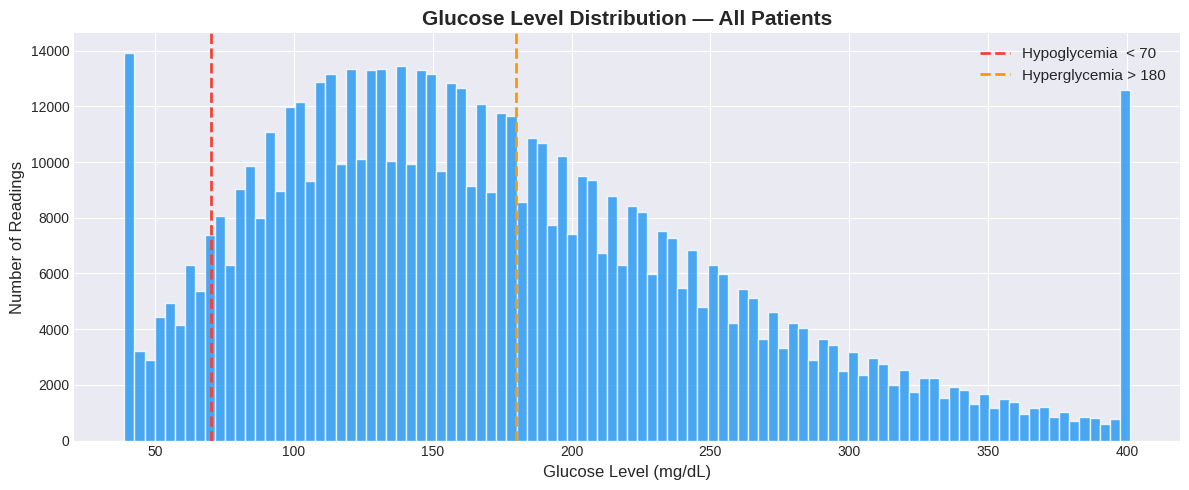

Mean  : 173.9 mg/dL
Median: 161.0 mg/dL
Std   : 82.5 mg/dL


In [17]:
plt.figure(figsize=(12, 5))

plt.hist(df['gl'], bins=100, color=COLORS['glucose'], edgecolor='white', alpha=0.8)

# Clinical threshold lines
plt.axvline(HYPO_THRESHOLD,  color=COLORS['hypo'],   linewidth=2, linestyle='--', label='Hypoglycemia  < 70')
plt.axvline(HYPER_THRESHOLD, color=COLORS['hyper'],  linewidth=2, linestyle='--', label='Hyperglycemia > 180')

plt.title('Glucose Level Distribution — All Patients', fontsize=15, fontweight='bold')
plt.xlabel('Glucose Level (mg/dL)', fontsize=12)
plt.ylabel('Number of Readings', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"Mean  : {df['gl'].mean():.1f} mg/dL")
print(f"Median: {df['gl'].median():.1f} mg/dL")
print(f"Std   : {df['gl'].std():.1f} mg/dL")

## Distribution of Glucose Zones
Patients spend over half of their time in hazardous glucose zones since only **51.4%** of values fall inside the normal range. The high rate of **41.1%** hyperglycemia significantly 

explains why a precise deep learning forecasting method is necessary.

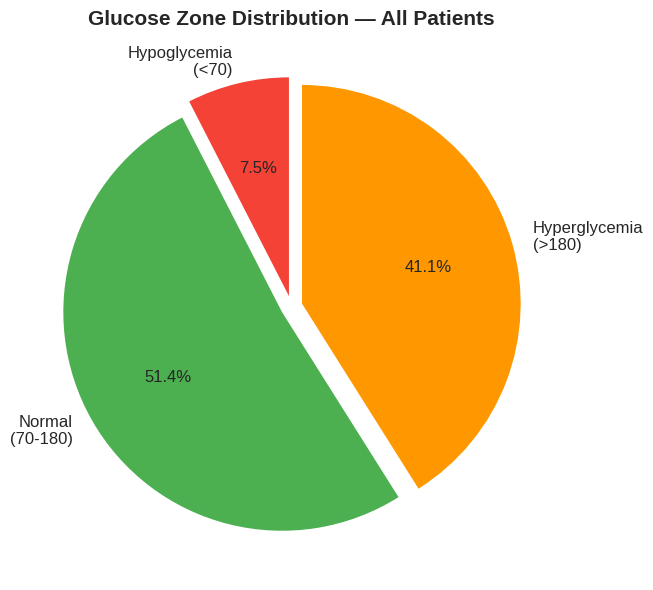

In [18]:
zones       = ['Hypoglycemia\n(<70)', 'Normal\n(70-180)', 'Hyperglycemia\n(>180)']
zone_counts = [
    (df['gl'] < 70).sum(),
    ((df['gl'] >= 70) & (df['gl'] <= 180)).sum(),
    (df['gl'] > 180).sum()
]
zone_colors = [COLORS['hypo'], COLORS['normal'], COLORS['hyper']]

plt.figure(figsize=(8, 6))
plt.pie(zone_counts,
        labels=zones,
        colors=zone_colors,
        autopct='%1.1f%%',
        startangle=90,
        explode=(0.05, 0.05, 0.05),
        textprops={'fontsize': 12})

plt.title('Glucose Zone Distribution — All Patients', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Patient Time Series 
Patient 1 exhibits extremely **volatile and non-linear** glucose patterns, with a mean of **213.8 mg/dL** with quick spikes and dips within brief periods. The use of sequence-based deep learning models such as CNN, GRU, and LSTM is directly justified by this chaotic behaviour.

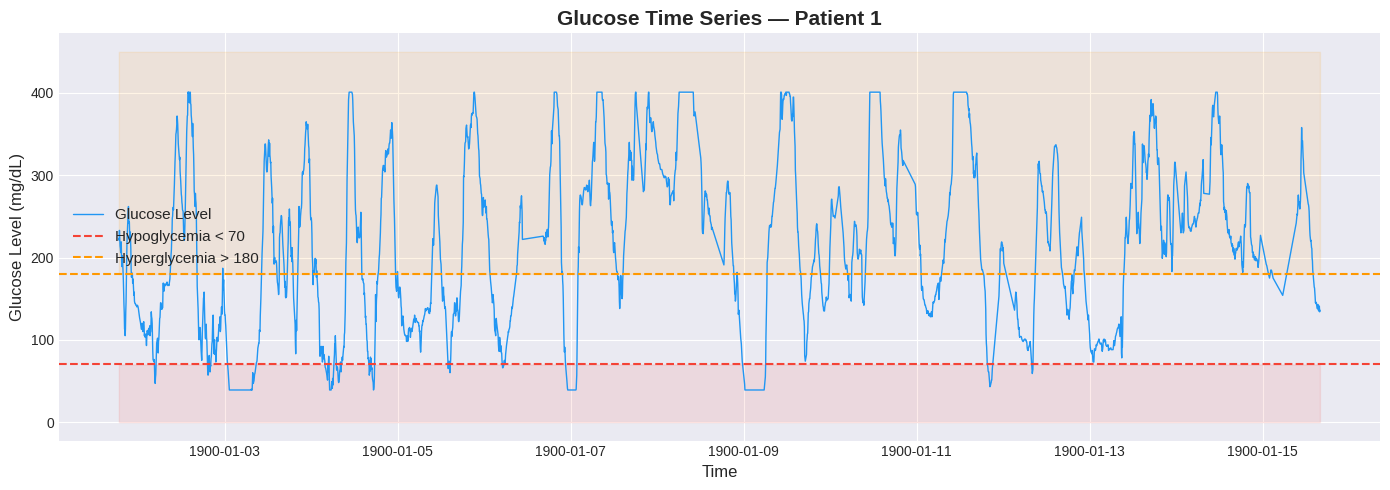

Patient 1 — Total readings : 3327
Mean glucose : 213.8 mg/dL


In [19]:
# Pick patient ID 1 as sample
patient = df[df['id'] == 1].copy()

plt.figure(figsize=(14, 5))

plt.plot(patient['time'], patient['gl'], 
         color=COLORS['glucose'], linewidth=1, label='Glucose Level')

# Clinical threshold lines
plt.axhline(HYPO_THRESHOLD,  color=COLORS['hypo'],  linewidth=1.5, 
            linestyle='--', label='Hypoglycemia < 70')
plt.axhline(HYPER_THRESHOLD, color=COLORS['hyper'], linewidth=1.5, 
            linestyle='--', label='Hyperglycemia > 180')

# Shade danger zones
plt.fill_between(patient['time'], 0, HYPO_THRESHOLD, 
                 alpha=0.1, color=COLORS['hypo'])
plt.fill_between(patient['time'], HYPER_THRESHOLD, 450, 
                 alpha=0.1, color=COLORS['hyper'])

plt.title('Glucose Time Series — Patient 1', fontsize=15, fontweight='bold')
plt.xlabel('Time', fontsize=12)
plt.ylabel('Glucose Level (mg/dL)', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"Patient 1 — Total readings : {len(patient)}")
print(f"Mean glucose : {patient['gl'].mean():.1f} mg/dL")

## Statistics by Patient
Patient data durations vary, with readings per patient ranging from **432 to 5,146**.
Personalised glucose forecasting models are necessary since the average of the top 10 patients is above **235 mg/dL**, indicating significant inter-patient variability.

In [20]:
patient_stats = df.groupby('id')['gl'].agg(
    Total_Readings = 'count',
    Mean_Glucose   = 'mean',
    Std_Glucose    = 'std',
    Min_Glucose    = 'min',
    Max_Glucose    = 'max'
).round(1).reset_index()

print("📊 Per Patient Glucose Statistics (Top 10 by Mean Glucose):")
print(patient_stats.sort_values('Mean_Glucose', ascending=False).head(10).to_string(index=False))

print(f"\n📈 Average readings per patient : {patient_stats['Total_Readings'].mean():.0f}")
print(f"📈 Overall mean glucose         : {patient_stats['Mean_Glucose'].mean():.1f} mg/dL")
print(f"📈 Most readings in one patient : {patient_stats['Total_Readings'].max()}")
print(f"📈 Least readings in one patient: {patient_stats['Total_Readings'].min()}")

📊 Per Patient Glucose Statistics (Top 10 by Mean Glucose):
 id  Total_Readings  Mean_Glucose  Std_Glucose  Min_Glucose  Max_Glucose
175            1838         265.4        111.5         44.0        401.0
171            2916         264.8         93.4         39.0        401.0
147            1869         248.2         99.4         39.0        401.0
166            2110         246.2         96.6         39.0        401.0
153            3007         243.7         96.9         65.0        401.0
 94            3713         242.2         71.6         82.0        401.0
 79             457         239.4         76.6        105.0        401.0
203            2316         237.3        119.3         39.0        401.0
184            1250         237.1         71.4         58.0        401.0
 93            3739         236.0         96.3         39.0        401.0

📈 Average readings per patient : 3239
📈 Overall mean glucose         : 175.3 mg/dL
📈 Most readings in one patient : 5146
📈 Least readings

## Time Gap Analysis
The majority of readings follow the expected 5-minute CGM sampling interval.
Large gaps (> 30 minutes) indicate missing readings periods, likely due to
sensor removal or device malfunction—these will need careful handling
during sequence creation to avoid feeding misleading patterns to the models.

📊 Time Gap Between Readings (minutes):
count    647658.00
mean          6.85
std         151.93
min           0.48
25%           5.00
50%           5.00
75%           5.00
max       66678.08
Name: time_diff, dtype: float64

✅ Exact 5-min gaps  : 610,852  (94.3%)
✅ Within 6 min gaps : 624,552  (96.4%)
⚠️  Gaps > 30 minutes : 2,553  (0.4%)


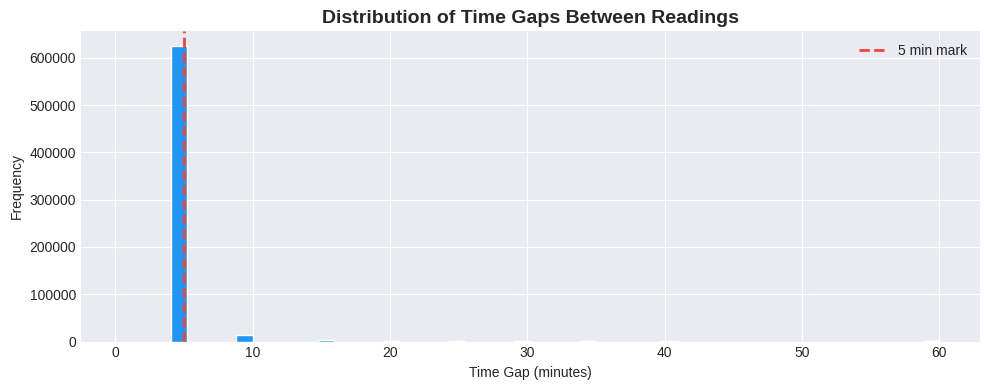

In [21]:
df['time_diff'] = df.groupby('id')['time'].diff().dt.total_seconds() / 60  # in minutes

# Overall stats
print("📊 Time Gap Between Readings (minutes):")
print(df['time_diff'].describe().round(2))

# How many gaps are exactly 5 minutes
exact_5 = (df['time_diff'] == 5).sum()
within_6 = (df['time_diff'] <= 6).sum()
large_gaps = (df['time_diff'] > 30).sum()

print(f"\n✅ Exact 5-min gaps  : {exact_5:,}  ({exact_5/df['time_diff'].notna().sum()*100:.1f}%)")
print(f"✅ Within 6 min gaps : {within_6:,}  ({within_6/df['time_diff'].notna().sum()*100:.1f}%)")
print(f"⚠️  Gaps > 30 minutes : {large_gaps:,}  ({large_gaps/df['time_diff'].notna().sum()*100:.1f}%)")

# Plot distribution of time gaps
plt.figure(figsize=(10, 4))
df['time_diff'].dropna().clip(upper=60).hist(bins=50, color=COLORS['glucose'], edgecolor='white')
plt.axvline(5, color=COLORS['hypo'], linewidth=2, linestyle='--', label='5 min mark')
plt.title('Distribution of Time Gaps Between Readings', fontsize=14, fontweight='bold')
plt.xlabel('Time Gap (minutes)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

## Rolling Mean Visualization
The 1-hour rolling mean smooths out short-term glucose spikes while preserving
the overall trend, revealing clear cyclical patterns of highs and lows throughout
the day. The 3-hour rolling mean shows the broader glucose trajectory, confirming
that this patient spends the majority of time in the hyperglycemic zone—a pattern
Our deep learning models must learn to forecast accurately.

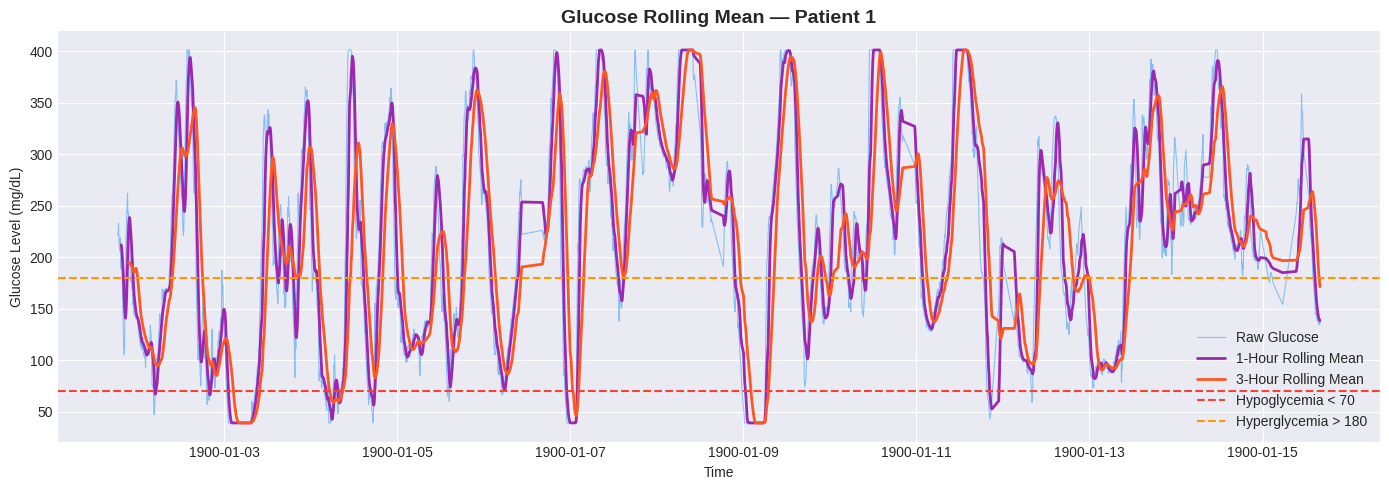

In [22]:
patient = df[df['id'] == 1].copy().reset_index(drop=True)

# Calculate rolling mean with different windows
patient['rolling_mean_12'] = patient['gl'].rolling(window=12).mean()  # 1 hour
patient['rolling_mean_36'] = patient['gl'].rolling(window=36).mean()  # 3 hours

plt.figure(figsize=(14, 5))

# Raw glucose
plt.plot(patient['time'], patient['gl'],
         color=COLORS['glucose'], linewidth=0.8, alpha=0.5, label='Raw Glucose')

# Rolling means
plt.plot(patient['time'], patient['rolling_mean_12'],
         color=COLORS['lstm'], linewidth=2, label='1-Hour Rolling Mean')
plt.plot(patient['time'], patient['rolling_mean_36'],
         color=COLORS['cnn'], linewidth=2, label='3-Hour Rolling Mean')

# Clinical thresholds
plt.axhline(HYPO_THRESHOLD,  color=COLORS['hypo'],  linewidth=1.5,
            linestyle='--', label='Hypoglycemia < 70')
plt.axhline(HYPER_THRESHOLD, color=COLORS['hyper'], linewidth=1.5,
            linestyle='--', label='Hyperglycemia > 180')

plt.title('Glucose Rolling Mean — Patient 1', fontsize=14, fontweight='bold')
plt.xlabel('Time')
plt.ylabel('Glucose Level (mg/dL)')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

## Glucose by Hour of Day
The plot reveals a clear daily glucose pattern—levels tend to be lower during
early morning hours (likely fasting/sleep period) and rise during daytime hours,
corresponding to meals and activity. The wide standard deviation band confirms
high variability between patients at every hour, reinforcing the need for
patient-specific forecasting models rather than a single global model.

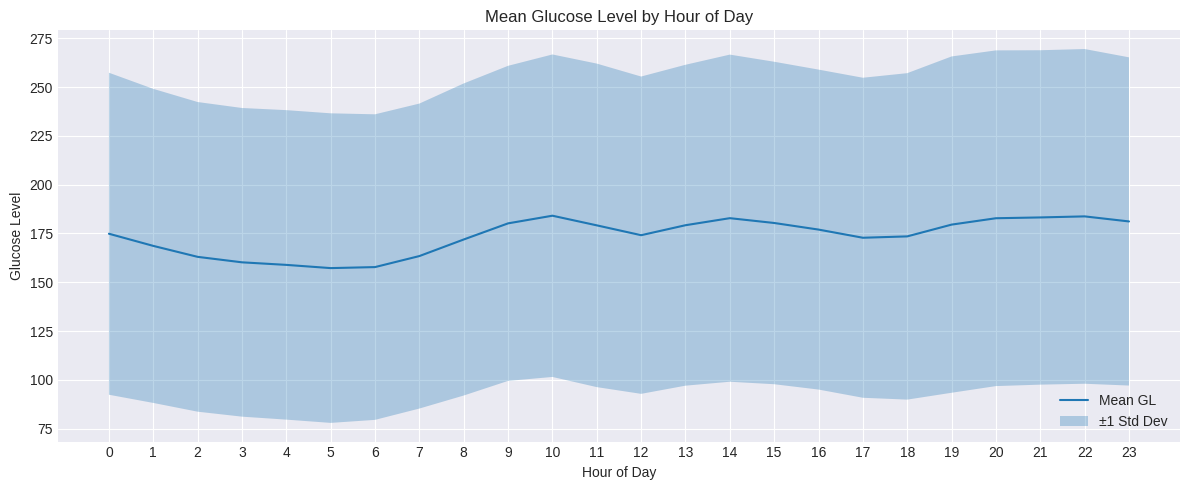

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(hourly_stats['hour'], hourly_stats['mean_gl'], label='Mean GL')
plt.fill_between(hourly_stats['hour'],
                 hourly_stats['mean_gl'] - hourly_stats['std_gl'],
                 hourly_stats['mean_gl'] + hourly_stats['std_gl'],
                 alpha=0.3, label='±1 Std Dev')
plt.xlabel('Hour of Day')
plt.ylabel('Glucose Level')
plt.title('Mean Glucose Level by Hour of Day')
plt.xticks(range(0, 24))
plt.legend()
plt.tight_layout()
plt.show()  # ← this is what forces it to render

## Correlation Heatmap
The correlation analysis reveals which clinical and demographic features
have the strongest linear relationship with glucose levels. Features with
higher positive correlation will be prioritised as additional inputs to
our deep learning models alongside the core CGM time series data.

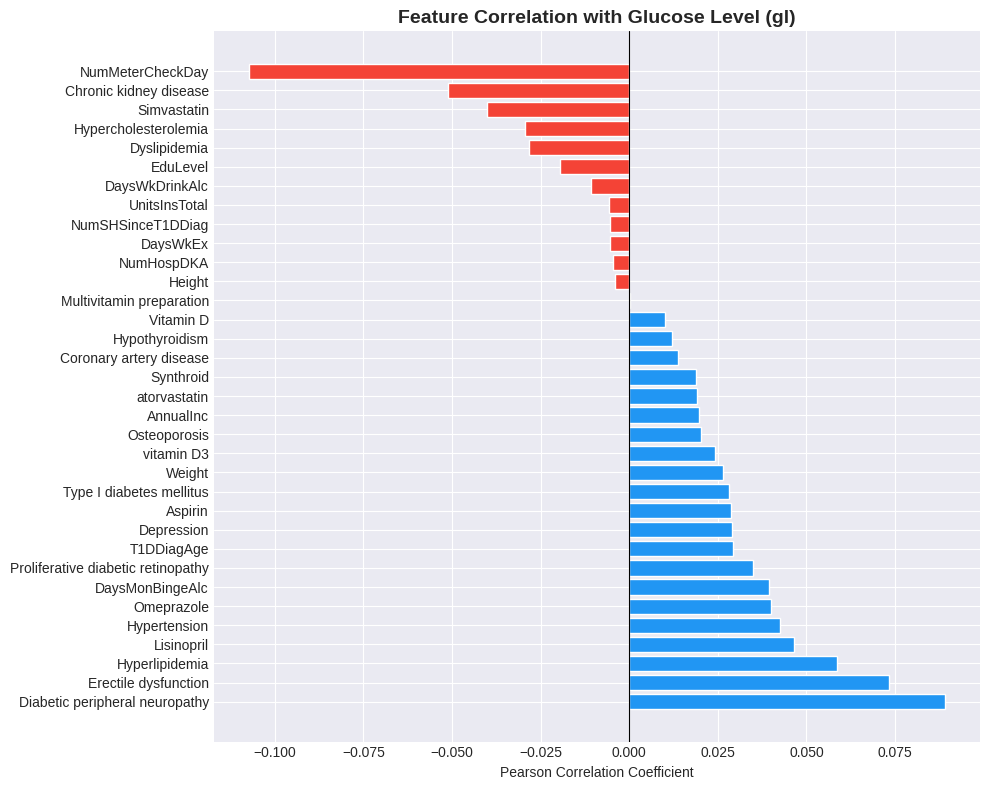


🔝 Top 5 Positively Correlated Features:
Diabetic peripheral neuropathy    0.089
Erectile dysfunction              0.073
Hyperlipidemia                    0.059
Lisinopril                        0.046
Hypertension                      0.043
Name: gl, dtype: float64

🔻 Top 5 Negatively Correlated Features:
Dyslipidemia             -0.028
Hypercholesterolemia     -0.029
Simvastatin              -0.040
Chronic kidney disease   -0.051
NumMeterCheckDay         -0.107
Name: gl, dtype: float64


In [46]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Remove non-useful columns
exclude = ['id', 'time_diff', 'hour', 'minute', 'dayofweek', 'is_night']
numeric_cols = [c for c in numeric_cols if c not in exclude]

# Compute correlation matrix
corr_matrix = df[numeric_cols].corr()

# Plot heatmap — focus on correlation with gl
gl_corr = corr_matrix['gl'].drop('gl').sort_values(ascending=False)

plt.figure(figsize=(10, 8))
colors = [COLORS['hypo'] if v < 0 else COLORS['glucose'] for v in gl_corr.values]
bars = plt.barh(gl_corr.index, gl_corr.values, color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Correlation with Glucose Level (gl)',
          fontsize=14, fontweight='bold')
plt.xlabel('Pearson Correlation Coefficient')
plt.tight_layout()
plt.show()

print("\n🔝 Top 5 Positively Correlated Features:")
print(gl_corr.head(5).round(3))
print("\n🔻 Top 5 Negatively Correlated Features:")
print(gl_corr.tail(5).round(3))

# Data Preprocessing

## Handle Outliers
Glucose values have been clipped to the clinically valid range of 40–400 mg/dL.
The 401 mg/dL spike we identified in EDA was the CGM sensor's maximum reading
cap rather than a true glucose value — capping at 400 ensures the model is not
misled by this artificial ceiling. No readings fell below the minimum threshold,
confirming the data is clinically realistic.

In [47]:
GL_MIN = 40    # Below this is clinically impossible for a live reading
GL_MAX = 400   # CGM sensor cap — treat 401 as sensor limit

print("📊 Before Clipping:")
print(f"   Min glucose : {df['gl'].min():.1f} mg/dL")
print(f"   Max glucose : {df['gl'].max():.1f} mg/dL")
print(f"   Readings below {GL_MIN} : {(df['gl'] < GL_MIN).sum():,}")
print(f"   Readings above {GL_MAX} : {(df['gl'] > GL_MAX).sum():,}")

# Clip glucose to clinical range
df['gl'] = df['gl'].clip(lower=GL_MIN, upper=GL_MAX)

print("\n📊 After Clipping:")
print(f"   Min glucose : {df['gl'].min():.1f} mg/dL")
print(f"   Max glucose : {df['gl'].max():.1f} mg/dL")
print(f"   Readings below {GL_MIN} : {(df['gl'] < GL_MIN).sum():,}")
print(f"   Readings above {GL_MAX} : {(df['gl'] > GL_MAX).sum():,}")

print("\n✅ Outlier clipping complete!")

📊 Before Clipping:
   Min glucose : 39.0 mg/dL
   Max glucose : 401.0 mg/dL
   Readings below 40 : 11,924
   Readings above 400 : 11,978

📊 After Clipping:
   Min glucose : 40.0 mg/dL
   Max glucose : 400.0 mg/dL
   Readings below 40 : 0
   Readings above 400 : 0

✅ Outlier clipping complete!


## Normalisation
Glucose values have been scaled to the [0, 1] range using MinMaxScaler.
This is a critical step for deep learning models—unnormalized values
cause unstable gradients and slow convergence during training.
The scaler parameters (min=40, max=400) must be saved and used later
to inverse transform model predictions back to mg/dL for evaluation.

In [48]:
from sklearn.preprocessing import MinMaxScaler

# Initialise scaler — fit only on glucose column
scaler = MinMaxScaler(feature_range=(0, 1))

# Fit and transform glucose column
df['gl_scaled'] = scaler.fit_transform(df[['gl']])

print("✅ Normalisation complete!")
print(f"\n   Original glucose range : {df['gl'].min():.1f} — {df['gl'].max():.1f} mg/dL")
print(f"   Scaled glucose range   : {df['gl_scaled'].min():.4f} — {df['gl_scaled'].max():.4f}")
print(f"\n   Scaler min : {scaler.data_min_[0]:.1f}")
print(f"   Scaler max : {scaler.data_max_[0]:.1f}")
print("\n⚠️  Scaler saved — needed later to inverse transform predictions back to mg/dL")

# Quick check
print(f"\n📋 Sample scaled values:")
print(df[['gl', 'gl_scaled']].head(8).to_string(index=False))

✅ Normalisation complete!

   Original glucose range : 40.0 — 400.0 mg/dL
   Scaled glucose range   : 0.0000 — 1.0000

   Scaler min : 40.0
   Scaler max : 400.0

⚠️  Scaler saved — needed later to inverse transform predictions back to mg/dL

📋 Sample scaled values:
   gl  gl_scaled
223.0   0.508333
221.0   0.502778
233.0   0.536111
223.0   0.508333
214.0   0.483333
211.0   0.475000
206.0   0.461111
208.0   0.466667


## Sequence Creation
The sliding window approach converts the raw time series into structured
input-output pairs for deep learning. Each input sequence contains
12 glucose readings (1 hour of history) and the target contains the
next 6 readings (30 minutes ahead). This formulation allows LSTM, GRU
and CNN models to learn temporal dependencies and forecast future
glucose trajectories from past patterns.

In [49]:
import numpy as np

def create_sequences(patient_data, seq_len=12, forecast_horizon=6):
    X, y = [], []
    gl = patient_data['gl_scaled'].values
    for i in range(len(gl) - seq_len - forecast_horizon + 1):
        X.append(gl[i : i + seq_len])
        y.append(gl[i + seq_len : i + seq_len + forecast_horizon])
    return np.array(X), np.array(y)

# Create sequences for all patients
all_X, all_y = [], []

for patient_id in df['id'].unique():
    patient_data = df[df['id'] == patient_id].copy()
    X, y = create_sequences(patient_data, SEQUENCE_LENGTH, FORECAST_HORIZON)
    if len(X) > 0:
        all_X.append(X)
        all_y.append(y)

# Stack all patients
X_all = np.concatenate(all_X, axis=0)
y_all = np.concatenate(all_y, axis=0)

# Reshape X for models — (samples, timesteps, features)
X_all = X_all.reshape(X_all.shape[0], X_all.shape[1], 1)

print("✅ Sequence creation complete!")
print(f"\n   Input shape  (X) : {X_all.shape}")
print(f"   Output shape (y) : {y_all.shape}")
print(f"\n   Each sample  : {SEQUENCE_LENGTH} steps ({SEQUENCE_LENGTH*5} mins) → predicts {FORECAST_HORIZON} steps ({FORECAST_HORIZON*5} mins)")
print(f"   Total sequences  : {X_all.shape[0]:,}")

✅ Sequence creation complete!

   Input shape  (X) : (644458, 12, 1)
   Output shape (y) : (644458, 6)

   Each sample  : 12 steps (60 mins) → predicts 6 steps (30 mins)
   Total sequences  : 644,458


## Train/Validation/Test Split
A time-based 70/15/15 split ensures no data leakage—the model only
ever trains on past data and is evaluated on truly unseen future sequences.
Random splitting would be inappropriate here, as it would allow future
glucose readings to influence model training, producing artificially
inflated performance metrics that would not hold in real clinical use.

In [50]:
total = len(X_all)

train_end = int(total * TRAIN_RATIO)
val_end   = int(total * (TRAIN_RATIO + VAL_RATIO))

# Split — time-based, no shuffling
X_train = X_all[:train_end]
y_train = y_all[:train_end]

X_val   = X_all[train_end:val_end]
y_val   = y_all[train_end:val_end]

X_test  = X_all[val_end:]
y_test  = y_all[val_end:]

print("✅ Train / Validation / Test Split Complete!")
print(f"\n   Total sequences : {total:,}")
print(f"\n   X_train : {X_train.shape}  — {len(X_train):,} samples ({TRAIN_RATIO*100:.0f}%)")
print(f"   X_val   : {X_val.shape}  — {len(X_val):,} samples ({VAL_RATIO*100:.0f}%)")
print(f"   X_test  : {X_test.shape}  — {len(X_test):,} samples ({TEST_RATIO*100:.0f}%)")

print(f"\n   y_train : {y_train.shape}")
print(f"   y_val   : {y_val.shape}")
print(f"   y_test  : {y_test.shape}")

# Memory usage
import sys
total_mb = (X_train.nbytes + X_val.nbytes + X_test.nbytes +
            y_train.nbytes + y_val.nbytes + y_test.nbytes) / 1024**2
print(f"\n💾 Total memory used : {total_mb:.1f} MB")

✅ Train / Validation / Test Split Complete!

   Total sequences : 644,458

   X_train : (451120, 12, 1)  — 451,120 samples (70%)
   X_val   : (96669, 12, 1)  — 96,669 samples (15%)
   X_test  : (96669, 12, 1)  — 96,669 samples (15%)

   y_train : (451120, 6)
   y_val   : (96669, 6)
   y_test  : (96669, 6)

💾 Total memory used : 88.5 MB
